In [4]:
"""
Chirp Signal Tracking with Dual-Group Stochastic Resonance
评估指标：
1. 瞬时跟踪误差的时变包络
2. 参数调整速度 (σ, W1, W2 的变化率)
3. 参数稳定性 (振荡检测)
4. 收敛速度 (达到稳态的时间)
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import scienceplots

# 启用 SciencePlots 样式
try:
    plt.style.use(['science', 'ieee'])
except:
    print("Warning: scienceplots style not found. Using default.")

plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix',
    'font.size': 10,
    'axes.labelsize': 10,
    'legend.fontsize': 8,
})

# ==========================================
# 辅助函数
# ==========================================
def gaussian_pdf(x):
    if isinstance(x, torch.Tensor):
        return (1.0 / np.sqrt(2 * np.pi)) * torch.exp(-0.5 * x**2)
    return (1.0 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

def generate_chirp_signal(Nx_total, f_start=0.005, f_end=0.05, amplitude=1.0, seed=42):
    """生成线性调频信号"""
    torch.manual_seed(seed)
    t = torch.arange(Nx_total, dtype=torch.float32)
    chirp_rate = (f_end - f_start) / Nx_total
    phase = 2 * np.pi * (f_start * t + 0.5 * chirp_rate * t**2)
    chirp_signal = amplitude * torch.sin(phase)
    return chirp_signal.reshape(-1, 1)

def run_chirp_tracking(input_signal, init_sigma, N1=15, N2=16, theta1=-0.5, theta2=0.5, 
                       seed_val=42, window_size=50):
    """使用双组阈值阵列跟踪Chirp信号"""
    torch.manual_seed(seed_val)
    np.random.seed(seed_val)
    
    Nx_total = input_signal.shape[0]
    
    # RLS 初始化
    W_vec = torch.tensor([[0.5], [0.5]], dtype=torch.float32)
    P_rls = torch.eye(2) * 10.0
    
    # EKF 初始化
    sigma_curr = init_sigma
    P_sigma = 2.0
    Q_sigma = 1e-3
    R_sigma = 1.0
    
    # 记录数组
    sigma_history = torch.zeros(Nx_total)
    W1_history = torch.zeros(Nx_total)
    W2_history = torch.zeros(Nx_total)
    H_k_history = torch.zeros(Nx_total)
    
    instantaneous_error = torch.zeros(Nx_total)
    instantaneous_mse = torch.zeros(Nx_total)
    windowed_mse = torch.zeros(Nx_total)
    
    sigma_rate = torch.zeros(Nx_total)
    W1_rate = torch.zeros(Nx_total)
    W2_rate = torch.zeros(Nx_total)
    
    y_hat_history = torch.zeros(Nx_total)
    
    for k in range(Nx_total):
        x_k = input_signal[k, 0]
        
        # 生成观测
        torch.manual_seed(seed_val + k * 100)
        noise_std = max(sigma_curr, 0.01)
        
        noise1 = noise_std * torch.randn(N1, 1)
        y1_vec = torch.sign(x_k + noise1 - theta1)
        phi1 = torch.mean(y1_vec)
        
        noise2 = noise_std * torch.randn(N2, 1)
        y2_vec = torch.sign(x_k + noise2 - theta2)
        phi2 = torch.mean(y2_vec)
        
        phi_vec = torch.tensor([[phi1], [phi2]])
        
        # Vector RLS 更新
        y_hat = torch.matmul(W_vec.T, phi_vec)
        e_k = x_k - y_hat
        
        numer = torch.matmul(P_rls, phi_vec)
        denom = torch.matmul(phi_vec.T, torch.matmul(P_rls, phi_vec)) + 0.1
        g_rls = numer / denom
        
        W_vec_old = W_vec.clone()
        W_vec = W_vec + g_rls * e_k
        P_rls = P_rls - torch.matmul(g_rls, torch.matmul(phi_vec.T, P_rls))
        
        # EKF 预测
        sigma_pred = sigma_curr
        P_pred = P_sigma + Q_sigma
        
        # 计算 Jacobian
        s_safe = max(sigma_pred, 0.01)
        
        u1 = (x_k - theta1) / s_safe
        pdf1 = gaussian_pdf(u1)
        h1 = -2.0 * W_vec[0].item() * ((x_k - theta1) / s_safe**2) * pdf1
        
        u2 = (x_k - theta2) / s_safe
        pdf2 = gaussian_pdf(u2)
        h2 = -2.0 * W_vec[1].item() * ((x_k - theta2) / s_safe**2) * pdf2
        
        H_k = h1 + h2
        
        # EKF 更新
        S_innov = H_k**2 * P_pred + R_sigma
        K_sigma = P_pred * H_k / S_innov
        
        step = K_sigma * e_k.item()
        step = max(min(step, 0.5), -0.5)
        
        sigma_old = sigma_curr
        sigma_new = sigma_pred + step
        sigma_new = max(min(sigma_new, 5.0), 0.03)
        P_sigma = (1 - K_sigma * H_k) * P_pred
        
        # 记录数据
        sigma_history[k] = sigma_curr
        W1_history[k] = W_vec[0].item()
        W2_history[k] = W_vec[1].item()
        H_k_history[k] = H_k
        y_hat_history[k] = y_hat.item()
        
        instantaneous_error[k] = e_k.item()
        instantaneous_mse[k] = e_k.item()**2
        
        # 计算变化率
        if k > 0:
            sigma_rate[k] = sigma_curr - sigma_old
            W1_rate[k] = W_vec[0].item() - W_vec_old[0].item()
            W2_rate[k] = W_vec[1].item() - W_vec_old[1].item()
        
        # 滑动平均 MSE
        if k < window_size:
            windowed_mse[k] = torch.mean(instantaneous_mse[:k+1]).item()
        else:
            windowed_mse[k] = torch.mean(instantaneous_mse[k-window_size+1:k+1]).item()
            
        sigma_curr = sigma_new
    
    return {
        'sigma_hist': sigma_history.numpy(),
        'W1_hist': W1_history.numpy(),
        'W2_hist': W2_history.numpy(),
        'H_k_hist': H_k_history.numpy(),
        'y_hat_hist': y_hat_history.numpy(),
        'error_hist': instantaneous_error.numpy(),
        'mse_hist': windowed_mse.numpy(),
        'sigma_rate': sigma_rate.numpy(),
        'W1_rate': W1_rate.numpy(),
        'W2_rate': W2_rate.numpy(),
        'input_signal': input_signal.squeeze().numpy()
    }

def compute_tracking_metrics(results, steady_start=1500):
    """计算跟踪性能指标"""
    Nx_total = len(results['error_hist'])
    metrics = {}
    
    # 1. 瞬时跟踪误差包络
    window = 100
    error_envelope = np.zeros(Nx_total)
    for i in range(Nx_total):
        start = max(0, i - window)
        error_envelope[i] = np.std(results['error_hist'][start:i+1])
    metrics['error_envelope'] = error_envelope
    
    # 2. 参数调整速度
    metrics['sigma_rate_rms'] = np.sqrt(np.mean(results['sigma_rate'][100:]**2))
    metrics['W1_rate_rms'] = np.sqrt(np.mean(results['W1_rate'][100:]**2))
    metrics['W2_rate_rms'] = np.sqrt(np.mean(results['W2_rate'][100:]**2))
    
    # 3. 参数稳定性
    def detect_oscillation(signal, lag_max=50):
        signal_norm = signal - np.mean(signal)
        autocorr = np.correlate(signal_norm, signal_norm, mode='full')
        autocorr = autocorr[len(autocorr)//2:]
        autocorr = autocorr / autocorr[0]
        
        peaks = []
        for i in range(2, min(lag_max, len(autocorr))):
            if autocorr[i] > autocorr[i-1] and autocorr[i] > autocorr[i+1]:
                if autocorr[i] > 0.3:
                    peaks.append((i, autocorr[i]))
        return peaks
    
    sigma_osc = detect_oscillation(results['sigma_hist'][steady_start:])
    W1_osc = detect_oscillation(results['W1_hist'][steady_start:])
    
    metrics['sigma_oscillation'] = len(sigma_osc) > 0
    metrics['W1_oscillation'] = len(W1_osc) > 0
    metrics['sigma_osc_period'] = sigma_osc[0][0] if sigma_osc else None
    metrics['W1_osc_period'] = W1_osc[0][0] if W1_osc else None
    
    # 4. 收敛速度（修正版）
    steady_mse = np.mean(results['mse_hist'][steady_start:])

    alpha = 1.1          # 110% 阈值（与论文一致）
    threshold = alpha * steady_mse
    L_confirm = 50       # 持续窗口长度（可写进论文）

    convergence_time = Nx_total  # 默认未收敛

    for k in range(0, Nx_total - L_confirm):
        if np.all(results['mse_hist'][k:k+L_confirm] < threshold):
            convergence_time = k
            break

    metrics['convergence_time'] = convergence_time

    
    # 稳态性能
    metrics['steady_mse'] = steady_mse
    metrics['steady_sigma'] = np.mean(results['sigma_hist'][steady_start:])
    metrics['steady_W1'] = np.mean(results['W1_hist'][steady_start:])
    metrics['steady_W2'] = np.mean(results['W2_hist'][steady_start:])
    
    return metrics

# ==========================================
# 主程序
# ==========================================
print("="*80)
print("CHIRP SIGNAL TRACKING WITH DUAL-GROUP STOCHASTIC RESONANCE")
print("="*80)

# 参数设置
Nx_total = 3000
f_start, f_end = 0.005, 0.05
amplitude = 1.0
init_sigma = 1.0
seed_val = 42

# 生成Chirp信号
print(f"\nGenerating Chirp signal...")
print(f"  Length: {Nx_total}")
print(f"  Frequency range: {f_start} → {f_end}")
print(f"  Amplitude: {amplitude}")

chirp_signal = generate_chirp_signal(Nx_total, f_start, f_end, amplitude, seed_val)

# 运行跟踪
print(f"\nRunning tracking algorithm...")
print(f"  Initial σ: {init_sigma}")
print(f"  Group 1: N=15, θ=-0.5")
print(f"  Group 2: N=16, θ=0.5")

results = run_chirp_tracking(chirp_signal, init_sigma, seed_val=seed_val)

# 计算评估指标
print(f"\nComputing performance metrics...")
metrics = compute_tracking_metrics(results)

# 打印评估结果
print("\n" + "="*80)
print("TRACKING PERFORMANCE METRICS")
print("="*80)

print(f"\n1. 瞬时跟踪误差:")
print(f"   Mean error envelope (steady-state): {np.mean(metrics['error_envelope'][1500:]):.6f}")
print(f"   Max error envelope: {np.max(metrics['error_envelope']):.6f}")

print(f"\n2. 参数调整速度 (RMS of rate of change):")
print(f"   σ rate: {metrics['sigma_rate_rms']:.6f}")
print(f"   w1 rate: {metrics['W1_rate_rms']:.6f}")
print(f"   w2 rate: {metrics['W2_rate_rms']:.6f}")

print(f"\n3. 参数稳定性:")
print(f"   σ oscillation detected: {metrics['sigma_oscillation']}")
if metrics['sigma_osc_period']:
    print(f"   σ oscillation period: {metrics['sigma_osc_period']} samples")
print(f"   w1 oscillation detected: {metrics['W1_oscillation']}")
if metrics['W1_osc_period']:
    print(f"   w1 oscillation period: {metrics['W1_osc_period']} samples")

print(f"\n4. 收敛速度:")
print(f"   Convergence time: {metrics['convergence_time']} samples")

print(f"\n5. 稳态性能:")
print(f"   Steady-state MSE: {metrics['steady_mse']:.6f}")
print(f"   Steady-state σ: {metrics['steady_sigma']:.4f}")
print(f"   Steady-state w1: {metrics['steady_W1']:.4f}")
print(f"   Steady-state w2: {metrics['steady_W2']:.4f}")

print("\n" + "="*80)

print("\nGenerating visualizations...")

# 保存结果供后续使用
np.savez('chirp_tracking_results.npz',
         **results,
         **metrics,
         Nx_total=Nx_total,
         f_start=f_start,
         f_end=f_end)

print("\nResults saved to: chirp_tracking_results.npz")
print("\nExperiment completed successfully!")

CHIRP SIGNAL TRACKING WITH DUAL-GROUP STOCHASTIC RESONANCE

Generating Chirp signal...
  Length: 3000
  Frequency range: 0.005 → 0.05
  Amplitude: 1.0

Running tracking algorithm...
  Initial σ: 1.0
  Group 1: N=15, θ=-0.5
  Group 2: N=16, θ=0.5

Computing performance metrics...

TRACKING PERFORMANCE METRICS

1. 瞬时跟踪误差:
   Mean error envelope (steady-state): 0.100140
   Max error envelope: 0.180710

2. 参数调整速度 (RMS of rate of change):
   σ rate: 0.000000
   w1 rate: 0.000232
   w2 rate: 0.000282

3. 参数稳定性:
   σ oscillation detected: False
   w1 oscillation detected: False

4. 收敛速度:
   Convergence time: 142 samples

5. 稳态性能:
   Steady-state MSE: 0.010128
   Steady-state σ: 0.3055
   Steady-state w1: 0.4897
   Steady-state w2: 0.4900


Generating visualizations...

Results saved to: chirp_tracking_results.npz

Experiment completed successfully!


CHIRP SIGNAL TRACKING WITH DUAL-GROUP STOCHASTIC RESONANCE

Generating Chirp signal...
  Length: 3000
  Frequency range: 0.005 → 0.05
  Amplitude: 1.0

Running tracking algorithm...
  Initial σ: 1.0
  Group 1: N=15, θ=-0.5
  Group 2: N=16, θ=0.5

Computing performance metrics...

TRACKING PERFORMANCE METRICS

1. 瞬时跟踪误差:
   Mean error envelope (steady-state): 0.100140
   Max error envelope: 0.180710

2. 参数调整速度 (RMS of rate of change):
   σ rate: 0.000000
   w1 rate: 0.000232
   w2 rate: 0.000282

3. 参数稳定性:
   σ oscillation detected: False
   w1 oscillation detected: False

4. 收敛速度:
   Convergence time: 142 samples

5. 稳态性能:
   Steady-state MSE: 0.010128
   Steady-state σ: 0.3055
   Steady-state w1: 0.4897
   Steady-state w2: 0.4900


Results saved for plotting.
Run the plotting script to visualize tracking performance.


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.



Figures saved:
  - chirp_tracking_performance.eps
  - chirp_tracking_performance.png


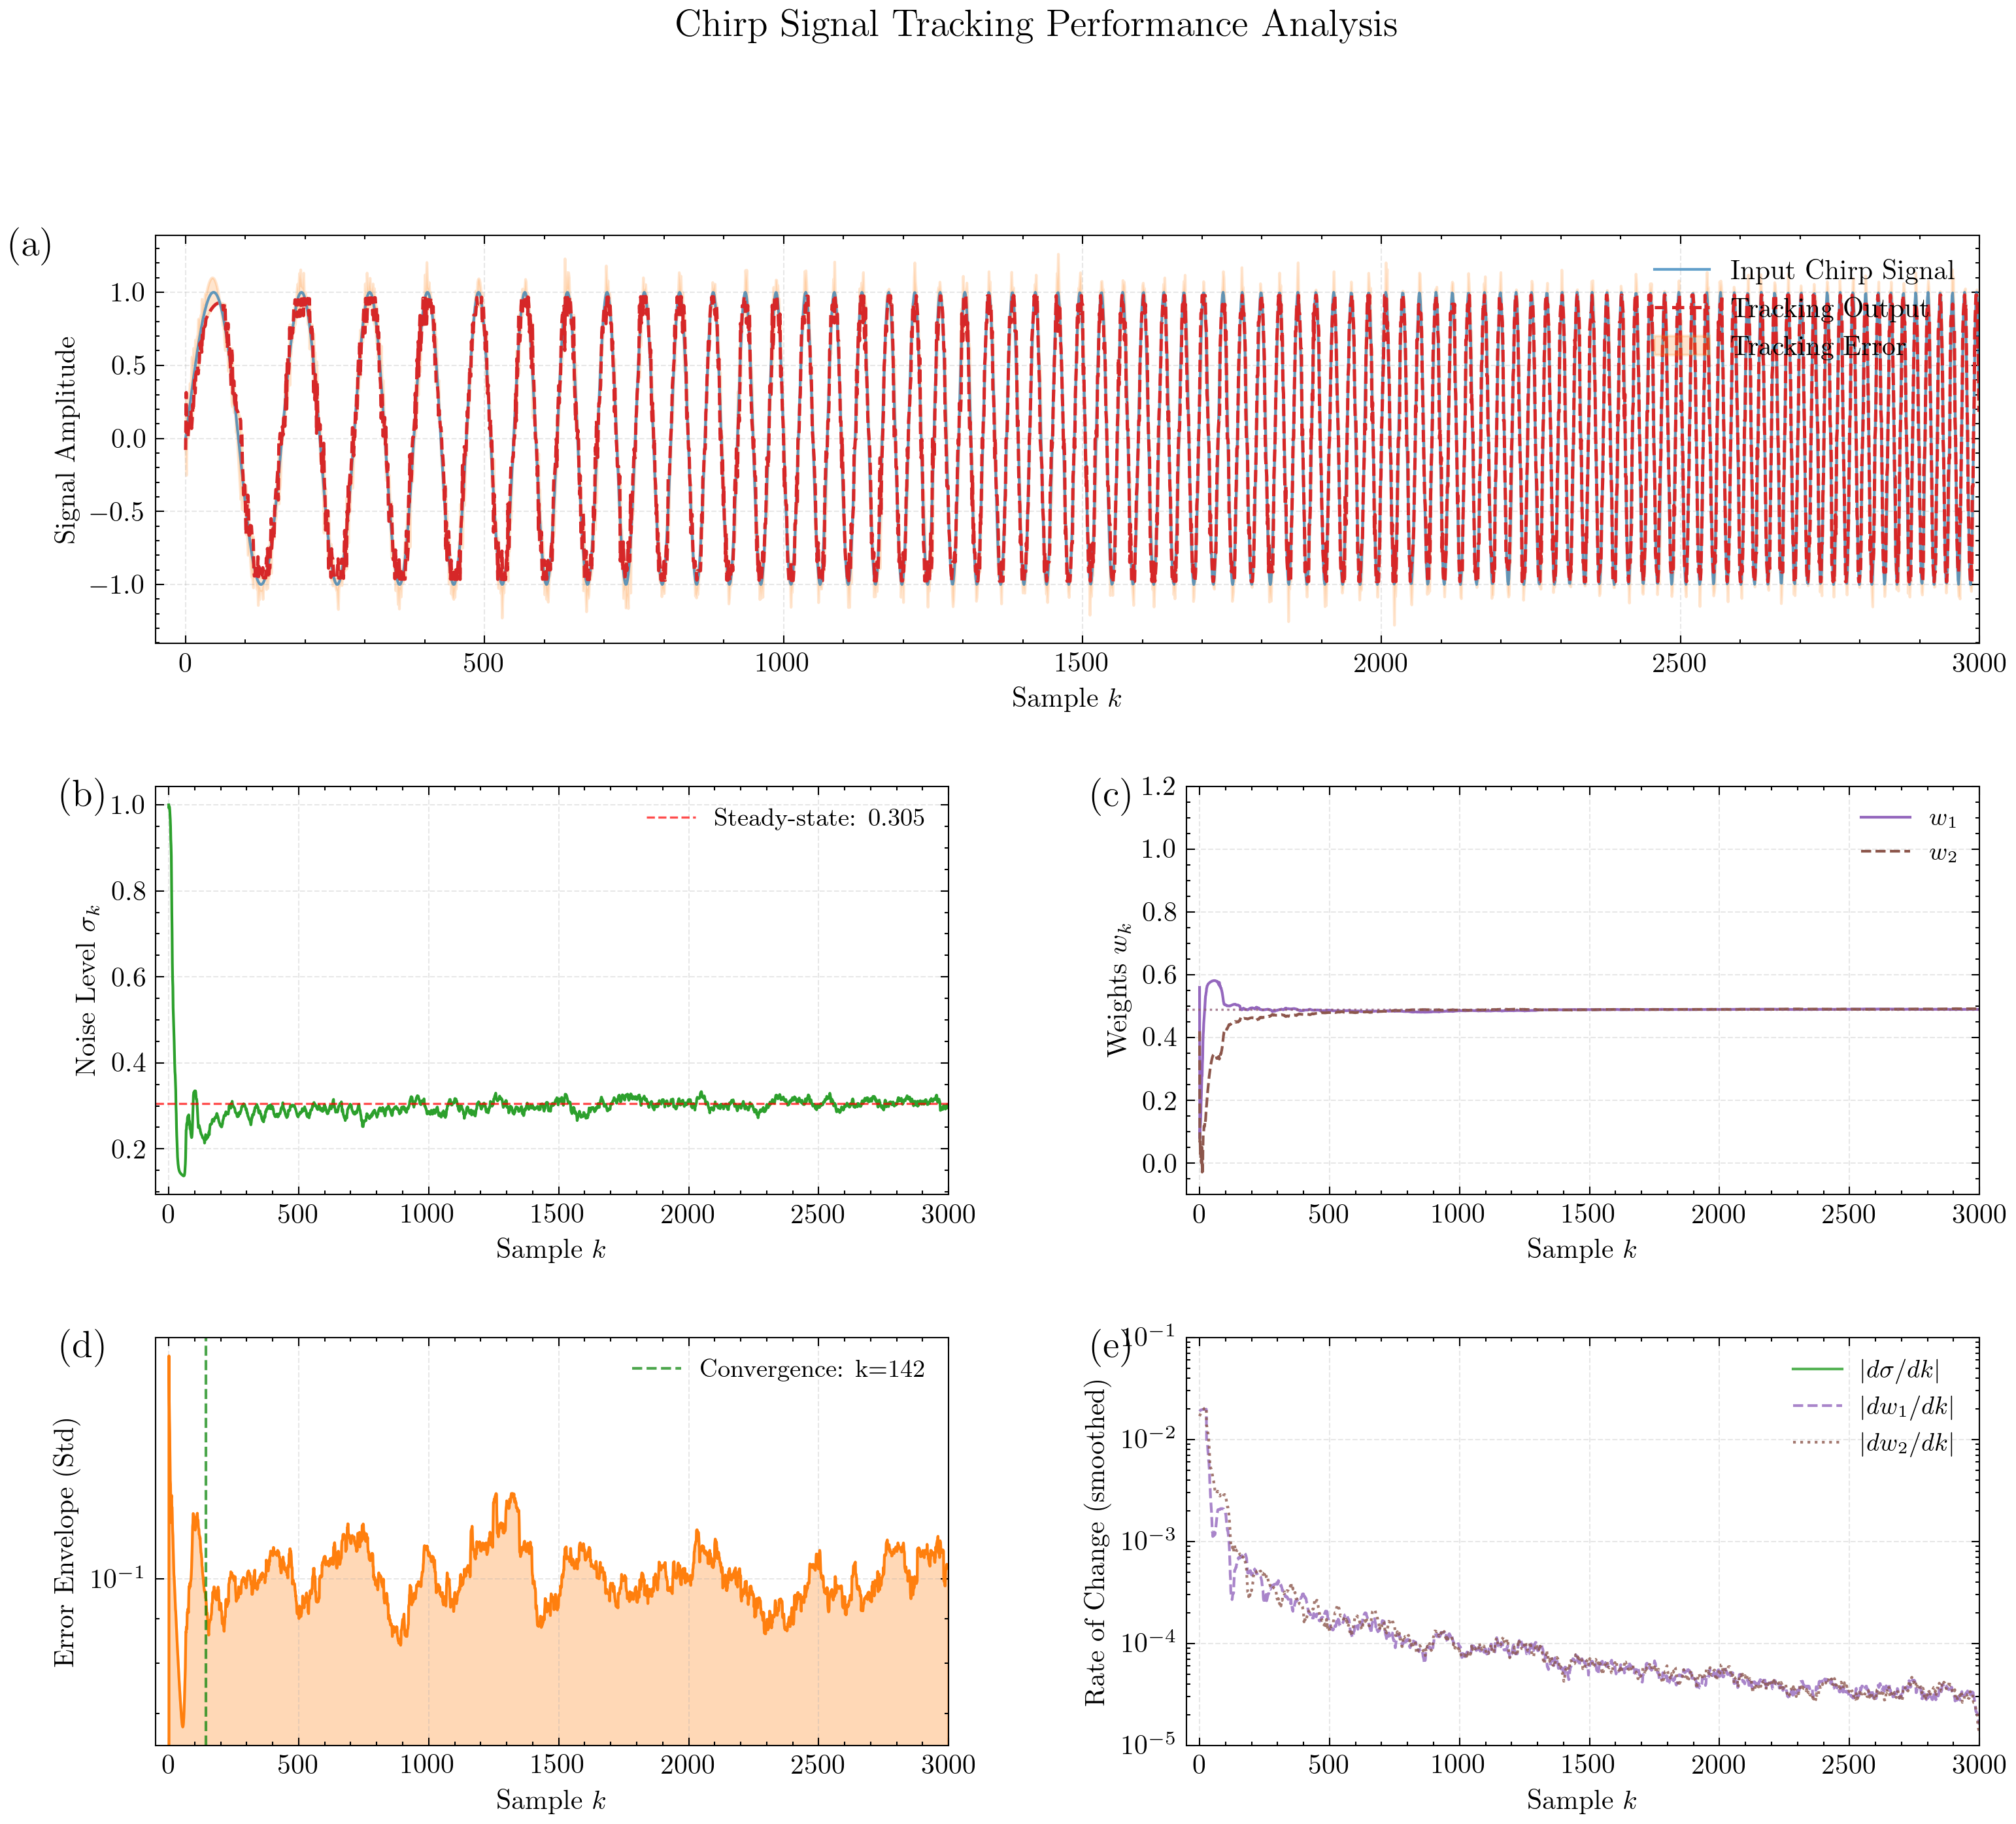

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import scienceplots

# 绘图设置
try:
    plt.style.use(['science', 'ieee'])
except:
    print("Warning: scienceplots style not found. Using default.")

plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 800
mpl.rcParams['axes.unicode_minus'] = False

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix',
    'font.size': 12,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
})
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
import scienceplots

# 启用 SciencePlots 样式
try:
    plt.style.use(['science', 'ieee'])
except:
    print("Warning: scienceplots style not found. Using default.")

plt.rcParams['font.serif'] = ['Times New Roman']
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix',
    'font.size': 10,
    'axes.labelsize': 10,
    'legend.fontsize': 8,
})

# ==========================================
# 辅助函数
# ==========================================
def gaussian_pdf(x):
    if isinstance(x, torch.Tensor):
        return (1.0 / np.sqrt(2 * np.pi)) * torch.exp(-0.5 * x**2)
    return (1.0 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

def generate_chirp_signal(Nx_total, f_start=0.005, f_end=0.05, amplitude=1.0, seed=42):
    """
    生成线性调频信号 (Chirp Signal)
    
    参数:
        Nx_total: 信号长度
        f_start: 起始归一化频率
        f_end: 结束归一化频率
        amplitude: 幅度
        seed: 随机种子
    """
    torch.manual_seed(seed)
    t = torch.arange(Nx_total, dtype=torch.float32)
    
    # 线性调频
    chirp_rate = (f_end - f_start) / Nx_total
    phase = 2 * np.pi * (f_start * t + 0.5 * chirp_rate * t**2)
    chirp_signal = amplitude * torch.sin(phase)
    
    return chirp_signal.reshape(-1, 1)

# ==========================================
# 核心跟踪函数: 分组 RLS + EKF (带详细记录)
# ==========================================
def run_chirp_tracking(input_signal, init_sigma, N1=15, N2=16, theta1=-0.5, theta2=0.5, 
                       seed_val=42, window_size=50):
    """
    使用双组阈值阵列跟踪Chirp信号
    
    返回详细的跟踪指标
    """
    torch.manual_seed(seed_val)
    np.random.seed(seed_val)
    
    Nx_total = input_signal.shape[0]
    
    # --- RLS 初始化 ---
    W_vec = torch.tensor([[0.5], [0.5]], dtype=torch.float32)
    P_rls = torch.eye(2) * 10.0
    
    # --- EKF 初始化 ---
    sigma_curr = init_sigma
    P_sigma = 2.0
    Q_sigma = 1e-3
    R_sigma = 1.0
    
    # --- 记录数组 ---
    sigma_history = torch.zeros(Nx_total)
    W1_history = torch.zeros(Nx_total)
    W2_history = torch.zeros(Nx_total)
    H_k_history = torch.zeros(Nx_total)
    
    # 核心指标
    instantaneous_error = torch.zeros(Nx_total)  # 瞬时误差 e_k
    instantaneous_mse = torch.zeros(Nx_total)    # e_k^2
    windowed_mse = torch.zeros(Nx_total)
    
    # 新增：参数变化率
    sigma_rate = torch.zeros(Nx_total)  # dσ/dk
    W1_rate = torch.zeros(Nx_total)     # dw1/dk
    W2_rate = torch.zeros(Nx_total)     # dw2/dk
    
    # 预测输出
    y_hat_history = torch.zeros(Nx_total)
    
    for k in range(Nx_total):
        x_k = input_signal[k, 0]
        
        # 1. 生成观测
        torch.manual_seed(seed_val + k * 100)
        noise_std = max(sigma_curr, 0.01)
        
        # Group 1
        noise1 = noise_std * torch.randn(N1, 1)
        y1_vec = torch.sign(x_k + noise1 - theta1)
        phi1 = torch.mean(y1_vec)
        
        # Group 2
        noise2 = noise_std * torch.randn(N2, 1)
        y2_vec = torch.sign(x_k + noise2 - theta2)
        phi2 = torch.mean(y2_vec)
        
        phi_vec = torch.tensor([[phi1], [phi2]])
        
        # 2. Vector RLS 更新
        y_hat = torch.matmul(W_vec.T, phi_vec)
        e_k = x_k - y_hat
        
        numer = torch.matmul(P_rls, phi_vec)
        denom = torch.matmul(phi_vec.T, torch.matmul(P_rls, phi_vec)) + 0.1
        g_rls = numer / denom
        
        W_vec_old = W_vec.clone()
        W_vec = W_vec + g_rls * e_k
        P_rls = P_rls - torch.matmul(g_rls, torch.matmul(phi_vec.T, P_rls))
        
        # 3. EKF 预测
        sigma_pred = sigma_curr
        P_pred = P_sigma + Q_sigma
        
        # 4. 计算 Jacobian H_k
        s_safe = max(sigma_pred, 0.01)
        
        u1 = (x_k - theta1) / s_safe
        pdf1 = gaussian_pdf(u1)
        h1 = -2.0 * W_vec[0].item() * ((x_k - theta1) / s_safe**2) * pdf1
        
        u2 = (x_k - theta2) / s_safe
        pdf2 = gaussian_pdf(u2)
        h2 = -2.0 * W_vec[1].item() * ((x_k - theta2) / s_safe**2) * pdf2
        
        H_k = h1 + h2
        
        # 5. EKF 更新
        S_innov = H_k**2 * P_pred + R_sigma
        K_sigma = P_pred * H_k / S_innov
        
        step = K_sigma * e_k.item()
        step = max(min(step, 0.5), -0.5)
        
        sigma_old = sigma_curr
        sigma_new = sigma_pred + step
        sigma_new = max(min(sigma_new, 5.0), 0.03)
        P_sigma = (1 - K_sigma * H_k) * P_pred
        
        # 6. 记录数据
        sigma_history[k] = sigma_curr
        W1_history[k] = W_vec[0].item()
        W2_history[k] = W_vec[1].item()
        H_k_history[k] = H_k
        y_hat_history[k] = y_hat.item()
        
        instantaneous_error[k] = e_k.item()
        instantaneous_mse[k] = e_k.item()**2
        
        # 计算变化率 (使用差分近似导数)
        if k > 0:
            sigma_rate[k] = sigma_curr - sigma_old
            W1_rate[k] = W_vec[0].item() - W_vec_old[0].item()
            W2_rate[k] = W_vec[1].item() - W_vec_old[1].item()
        
        # 滑动平均 MSE
        if k < window_size:
            windowed_mse[k] = torch.mean(instantaneous_mse[:k+1]).item()
        else:
            windowed_mse[k] = torch.mean(instantaneous_mse[k-window_size+1:k+1]).item()
            
        sigma_curr = sigma_new
    
    return {
        'sigma_hist': sigma_history.numpy(),
        'W1_hist': W1_history.numpy(),
        'W2_hist': W2_history.numpy(),
        'H_k_hist': H_k_history.numpy(),
        'y_hat_hist': y_hat_history.numpy(),
        'error_hist': instantaneous_error.numpy(),
        'mse_hist': windowed_mse.numpy(),
        'sigma_rate': sigma_rate.numpy(),
        'W1_rate': W1_rate.numpy(),
        'W2_rate': W2_rate.numpy(),
        'input_signal': input_signal.squeeze().numpy()
    }

# ==========================================
# 评估指标计算
# ==========================================
def compute_tracking_metrics(results, steady_start=1500):
    """
    计算跟踪性能指标
    
    1. 瞬时跟踪误差包络
    2. 参数调整速度
    3. 参数稳定性（振荡检测）
    4. 收敛速度
    """
    Nx_total = len(results['error_hist'])
    
    metrics = {}
    
    # 1. 瞬时跟踪误差包络 (使用移动窗口计算)
    window = 100
    error_envelope = np.zeros(Nx_total)
    for i in range(Nx_total):
        start = max(0, i - window)
        error_envelope[i] = np.std(results['error_hist'][start:i+1])
    metrics['error_envelope'] = error_envelope
    
    # 2. 参数调整速度 (变化率的RMS)
    metrics['sigma_rate_rms'] = np.sqrt(np.mean(results['sigma_rate'][100:]**2))
    metrics['W1_rate_rms'] = np.sqrt(np.mean(results['W1_rate'][100:]**2))
    metrics['W2_rate_rms'] = np.sqrt(np.mean(results['W2_rate'][100:]**2))
    
    # 3. 参数稳定性 (检测振荡)
    # 使用自相关函数检测周期性振荡
    def detect_oscillation(signal, lag_max=50):
        signal_norm = signal - np.mean(signal)
        autocorr = np.correlate(signal_norm, signal_norm, mode='full')
        autocorr = autocorr[len(autocorr)//2:]
        autocorr = autocorr / autocorr[0]  # 归一化
        
        # 寻找第一个显著的非零峰值
        peaks = []
        for i in range(2, min(lag_max, len(autocorr))):
            if autocorr[i] > autocorr[i-1] and autocorr[i] > autocorr[i+1]:
                if autocorr[i] > 0.3:  # 阈值
                    peaks.append((i, autocorr[i]))
        
        return peaks
    
    sigma_osc = detect_oscillation(results['sigma_hist'][steady_start:])
    W1_osc = detect_oscillation(results['W1_hist'][steady_start:])
    
    metrics['sigma_oscillation'] = len(sigma_osc) > 0
    metrics['W1_oscillation'] = len(W1_osc) > 0
    metrics['sigma_osc_period'] = sigma_osc[0][0] if sigma_osc else None
    metrics['W1_osc_period'] = W1_osc[0][0] if W1_osc else None
    
    # 4. 收敛速度 (基于MSE下降到稳态值的时间)
    # 4. 收敛速度（修正版）
    steady_mse = np.mean(results['mse_hist'][steady_start:])

    alpha = 1.1          # 110% 阈值（与论文一致）
    threshold = alpha * steady_mse
    L_confirm = 50       # 持续窗口长度（可写进论文）

    convergence_time = Nx_total  # 默认未收敛

    for k in range(0, Nx_total - L_confirm):
        if np.all(results['mse_hist'][k:k+L_confirm] < threshold):
            convergence_time = k
            break

    metrics['convergence_time'] = convergence_time
    
    # 稳态性能
    metrics['steady_mse'] = steady_mse
    metrics['steady_sigma'] = np.mean(results['sigma_hist'][steady_start:])
    metrics['steady_W1'] = np.mean(results['W1_hist'][steady_start:])
    metrics['steady_W2'] = np.mean(results['W2_hist'][steady_start:])
    
    return metrics

# ==========================================
# 主程序：运行跟踪实验
# ==========================================
print("="*80)
print("CHIRP SIGNAL TRACKING WITH DUAL-GROUP STOCHASTIC RESONANCE")
print("="*80)

# 参数设置
Nx_total = 3000
f_start, f_end = 0.005, 0.05
amplitude = 1.0
init_sigma = 1.0
seed_val = 42

# 生成Chirp信号
print(f"\nGenerating Chirp signal...")
print(f"  Length: {Nx_total}")
print(f"  Frequency range: {f_start} → {f_end}")
print(f"  Amplitude: {amplitude}")

chirp_signal = generate_chirp_signal(Nx_total, f_start, f_end, amplitude, seed_val)

# 运行跟踪
print(f"\nRunning tracking algorithm...")
print(f"  Initial σ: {init_sigma}")
print(f"  Group 1: N=15, θ=-0.5")
print(f"  Group 2: N=16, θ=0.5")

results = run_chirp_tracking(chirp_signal, init_sigma, seed_val=seed_val)

# 计算评估指标
print(f"\nComputing performance metrics...")
metrics = compute_tracking_metrics(results)

# 打印评估结果
print("\n" + "="*80)
print("TRACKING PERFORMANCE METRICS")
print("="*80)

print(f"\n1. 瞬时跟踪误差:")
print(f"   Mean error envelope (steady-state): {np.mean(metrics['error_envelope'][1500:]):.6f}")
print(f"   Max error envelope: {np.max(metrics['error_envelope']):.6f}")

print(f"\n2. 参数调整速度 (RMS of rate of change):")
print(f"   σ rate: {metrics['sigma_rate_rms']:.6f}")
print(f"   w1 rate: {metrics['W1_rate_rms']:.6f}")
print(f"   w2 rate: {metrics['W2_rate_rms']:.6f}")

print(f"\n3. 参数稳定性:")
print(f"   σ oscillation detected: {metrics['sigma_oscillation']}")
if metrics['sigma_osc_period']:
    print(f"   σ oscillation period: {metrics['sigma_osc_period']} samples")
print(f"   w1 oscillation detected: {metrics['W1_oscillation']}")
if metrics['W1_osc_period']:
    print(f"   w1 oscillation period: {metrics['W1_osc_period']} samples")

print(f"\n4. 收敛速度:")
print(f"   Convergence time: {metrics['convergence_time']} samples")

print(f"\n5. 稳态性能:")
print(f"   Steady-state MSE: {metrics['steady_mse']:.6f}")
print(f"   Steady-state σ: {metrics['steady_sigma']:.4f}")
print(f"   Steady-state w1: {metrics['steady_W1']:.4f}")
print(f"   Steady-state w2: {metrics['steady_W2']:.4f}")

print("\n" + "="*80)

# 保存结果供绘图使用
tracking_results = {
    'results': results,
    'metrics': metrics,
    'signal_params': {
        'Nx_total': Nx_total,
        'f_start': f_start,
        'f_end': f_end,
        'amplitude': amplitude
    }
}

print("\nResults saved for plotting.")
print("Run the plotting script to visualize tracking performance.")
def lighten_color(color, amount=0.7):
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], 1 - amount * (1 - c[1]), c[2])

# ==========================================
# 创建多面板图：6个子图
# ==========================================
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.30)

axes = [
    fig.add_subplot(gs[0, :]),  # ax1: 信号跟踪 (占据整个第一行)
    fig.add_subplot(gs[1, 0]),  # ax2: σ收敛
    fig.add_subplot(gs[1, 1]),  # ax3: W收敛
    fig.add_subplot(gs[2, 0]),  # ax4: 瞬时误差包络
    fig.add_subplot(gs[2, 1]),  # ax5: 参数变化率
]

labels_txt = ['(a)', '(b)', '(c)', '(d)', '(e)']

# 从之前运行的结果获取数据
results = tracking_results['results']
metrics = tracking_results['metrics']
Nx_total = tracking_results['signal_params']['Nx_total']

iterations = np.arange(Nx_total)

# 颜色方案
color_signal = '#1f77b4'
color_tracking = '#d62728'
color_error = '#ff7f0e'
color_sigma = '#2ca02c'
color_W1 = '#9467bd'
color_W2 = '#8c564b'

# ==========================================
# Panel (a): 信号跟踪效果
# ==========================================
ax1 = axes[0]

# 绘制原始信号
ax1.plot(iterations, results['input_signal'], 
         color=color_signal, linewidth=1.0, alpha=0.7,
         label='Input Chirp Signal')

# 绘制跟踪输出
ax1.plot(iterations, results['y_hat_hist'], 
         color=color_tracking, linewidth=1.2, linestyle='--',
         label='Tracking Output')

# 标注误差包络（填充区域）
error = results['error_hist']
ax1.fill_between(iterations, 
                 results['input_signal'] - np.abs(error),
                 results['input_signal'] + np.abs(error),
                 color=color_error, alpha=0.2, label='Tracking Error')

ax1.legend(loc='upper right', fontsize=10)
ax1.set_xlabel(r'Sample $k$')
ax1.set_ylabel(r'Signal Amplitude')
ax1.set_xlim(-50, Nx_total)
ax1.grid(alpha=0.3, linestyle='--', linewidth=0.5)
ax1.text(-0.08, 1.02, labels_txt[0], transform=ax1.transAxes,
         fontsize=14, va='top', fontweight='bold')

# ==========================================
# Panel (b): σ 收敛曲线
# ==========================================
ax2 = axes[1]

ax2.plot(iterations, results['sigma_hist'], 
         color=color_sigma, linewidth=1.0)

# 标注稳态值
steady_sigma = metrics['steady_sigma']
ax2.axhline(steady_sigma, color='red', linestyle='--', 
            linewidth=0.8, alpha=0.7,
            label=f'Steady-state: {steady_sigma:.3f}')

ax2.legend(loc='upper right', fontsize=9)
ax2.set_xlabel(r'Sample $k$')
ax2.set_ylabel(r'Noise Level $\sigma_k$')
ax2.set_xlim(-50, Nx_total)
ax2.grid(alpha=0.3, linestyle='--', linewidth=0.5)
ax2.text(-0.12, 1.02, labels_txt[1], transform=ax2.transAxes,
         fontsize=14, va='top', fontweight='bold')

# ==========================================
# Panel (c): W1 和 W2 收敛曲线
# ==========================================
ax3 = axes[2]

ax3.plot(iterations, results['W1_hist'], 
         color=color_W1, linewidth=1.0, linestyle='-',
         label=r'$w_1$')
ax3.plot(iterations, results['W2_hist'], 
         color=color_W2, linewidth=1.0, linestyle='--',
         label=r'$w_2$')

# 标注稳态值
ax3.axhline(metrics['steady_W1'], color=color_W1, 
            linestyle=':', linewidth=0.8, alpha=0.5)
ax3.axhline(metrics['steady_W2'], color=color_W2, 
            linestyle=':', linewidth=0.8, alpha=0.5)

ax3.legend(loc='upper right', fontsize=9)
ax3.set_xlabel(r'Sample $k$')
ax3.set_ylabel(r'Weights $w_k$')
ax3.set_xlim(-50, Nx_total)
ax3.set_ylim(-0.1, 1.2)
ax3.grid(alpha=0.3, linestyle='--', linewidth=0.5)
ax3.text(-0.12, 1.02, labels_txt[2], transform=ax3.transAxes,
         fontsize=14, va='top', fontweight='bold')

# ==========================================
# Panel (d): 瞬时跟踪误差包络
# ==========================================
ax4 = axes[3]

# 绘制误差包络
ax4.plot(iterations, metrics['error_envelope'], 
         color=color_error, linewidth=1.0)

# 填充区域
ax4.fill_between(iterations, 0, metrics['error_envelope'],
                 color=color_error, alpha=0.3)

# 标注收敛点
conv_time = metrics['convergence_time']
ax4.axvline(conv_time, color='green', linestyle='--', 
            linewidth=1.0, alpha=0.7,
            label=f'Convergence: k={conv_time}')

ax4.legend(loc='upper right', fontsize=9)
ax4.set_xlabel(r'Sample $k$')
ax4.set_ylabel(r'Error Envelope (Std)')
ax4.set_xlim(-50, Nx_total)
ax4.set_yscale('log')
ax4.grid(alpha=0.3, linestyle='--', linewidth=0.5)
ax4.text(-0.12, 1.02, labels_txt[3], transform=ax4.transAxes,
         fontsize=14, va='top', fontweight='bold')

# ==========================================
# Panel (e): 参数变化率 (Rate of Change)
# ==========================================
ax5 = axes[4]

# 计算变化率的移动平均（平滑显示）
window = 50
sigma_rate_smooth = np.convolve(np.abs(results['sigma_rate']), 
                                np.ones(window)/window, mode='same')
W1_rate_smooth = np.convolve(np.abs(results['W1_rate']), 
                             np.ones(window)/window, mode='same')
W2_rate_smooth = np.convolve(np.abs(results['W2_rate']), 
                             np.ones(window)/window, mode='same')

ax5.plot(iterations, sigma_rate_smooth, 
         color=color_sigma, linewidth=1.0, alpha=0.8,
         label=r'$|d\sigma/dk|$')
ax5.plot(iterations, W1_rate_smooth, 
         color=color_W1, linewidth=1.0, alpha=0.8,
         label=r'$|dw_1/dk|$')
ax5.plot(iterations, W2_rate_smooth, 
         color=color_W2, linewidth=1.0, alpha=0.8,
         label=r'$|dw_2/dk|$')

ax5.legend(loc='upper right', fontsize=9)
ax5.set_xlabel(r'Sample $k$')
ax5.set_ylabel(r'Rate of Change (smoothed)')
ax5.set_xlim(-50, Nx_total)
ax5.set_yscale('log')
ax5.set_ylim(1e-5, 1e-1)
ax5.grid(alpha=0.3, linestyle='--', linewidth=0.5)
ax5.text(-0.12, 1.02, labels_txt[4], transform=ax5.transAxes,
         fontsize=14, va='top', fontweight='bold')

# ==========================================
# 添加总标题
# ==========================================
fig.suptitle('Chirp Signal Tracking Performance Analysis', 
             fontsize=14, fontweight='bold', y=0.995)

# 保存图像
plt.savefig('chirp_tracking_performance.eps', 
            format='eps', dpi=800, bbox_inches='tight')
plt.savefig('chirp_tracking_performance.png', 
            format='png', dpi=300, bbox_inches='tight')

print("\nFigures saved:")
print("  - chirp_tracking_performance.eps")
print("  - chirp_tracking_performance.png")

plt.show()

# ==========================================
# 额外：创建参数稳定性分析图（振荡检测）
# ==========================================
if metrics['sigma_oscillation'] or metrics['W1_oscillation']:
    print("\nDetected oscillations in parameters - creating additional analysis...")
    
    fig_osc, axes_osc = plt.subplots(2, 1, figsize=(10, 6))
    
    # 只分析稳态部分
    steady_start = 1500
    steady_iter = iterations[steady_start:]
    
    # σ 的自相关
    ax_osc1 = axes_osc[0]
    sigma_steady = results['sigma_hist'][steady_start:]
    sigma_norm = sigma_steady - np.mean(sigma_steady)
    autocorr_sigma = np.correlate(sigma_norm, sigma_norm, mode='full')
    autocorr_sigma = autocorr_sigma[len(autocorr_sigma)//2:]
    autocorr_sigma = autocorr_sigma / autocorr_sigma[0]
    
    lags = np.arange(len(autocorr_sigma))
    ax_osc1.plot(lags[:200], autocorr_sigma[:200], color=color_sigma, linewidth=1.5)
    ax_osc1.axhline(0, color='black', linestyle='--', linewidth=0.5)
    ax_osc1.axhline(0.3, color='red', linestyle=':', linewidth=0.5, alpha=0.5, label='Threshold')
    ax_osc1.set_xlabel('Lag')
    ax_osc1.set_ylabel(r'Autocorrelation of $\sigma_k$')
    ax_osc1.set_title('Parameter Stability Analysis: Autocorrelation')
    ax_osc1.legend()
    ax_osc1.grid(alpha=0.3)
    
    # W1 的自相关
    ax_osc2 = axes_osc[1]
    W1_steady = results['W1_hist'][steady_start:]
    W1_norm = W1_steady - np.mean(W1_steady)
    autocorr_W1 = np.correlate(W1_norm, W1_norm, mode='full')
    autocorr_W1 = autocorr_W1[len(autocorr_W1)//2:]
    autocorr_W1 = autocorr_W1 / autocorr_W1[0]
    
    ax_osc2.plot(lags[:200], autocorr_W1[:200], color=color_W1, linewidth=1.5)
    ax_osc2.axhline(0, color='black', linestyle='--', linewidth=0.5)
    ax_osc2.axhline(0.3, color='red', linestyle=':', linewidth=0.5, alpha=0.5, label='Threshold')
    ax_osc2.set_xlabel('Lag')
    ax_osc2.set_ylabel(r'Autocorrelation of $w_1$')
    ax_osc2.legend()
    ax_osc2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('parameter_stability_analysis.png', dpi=300, bbox_inches='tight')
    print("  - parameter_stability_analysis.png")
    
    plt.show()